# =========================================================
#  Phase 4: Machine Learning — Random Forest Modeling
# =========================================================

OBJECTIVE:
Train a robust Random Forest Classifier to predict Mortality Risk based on 
economic, health, and temporal signals.

FOCUS AREAS:
- Model Training: Fitting the Random Forest algorithm on 3,640 samples.
- Performance Evaluation: Analyzing Precision, Recall, and F1-Score.
- Feature Importance: Identifying the top drivers of global mortality risk.

GOAL:
Build a reliable predictive system that classifies countries into risk zones 
with high accuracy.

### Step 1: Loading Prepared Data

In [1]:
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD DATA
# Accessing the pre-processed splits and features from Notebook 3
data = joblib.load('data_for_modeling.pkl')

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
features = data['features']
le = data['le']

print("Success: Training and Testing data loaded.")

Success: Training and Testing data loaded.


### Step 2: Training the Random Forest Model

In [2]:
# INITIALIZE MODEL
# Using 100 trees and a fixed random state for reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# TRAIN MODEL
# Fitting the model to our training data
rf_model.fit(X_train, y_train)

print("Success: Random Forest Model Trained.")

Success: Random Forest Model Trained.


### Step 3: Model Prediction & Evaluation

In [3]:
# PREDICTION
# Testing the model on unseen data (X_test)
y_pred = rf_model.predict(X_test)

# EVALUATION METRICS
# Printing accuracy and detailed report (Precision, Recall, F1)
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Overall Accuracy: 93.96%

Detailed Classification Report:
              precision    recall  f1-score   support

        High       0.96      0.94      0.95       299
         Low       0.98      0.94      0.96       305
      Medium       0.89      0.93      0.91       306

    accuracy                           0.94       910
   macro avg       0.94      0.94      0.94       910
weighted avg       0.94      0.94      0.94       910



### Step 4: Visualizing the Confusion Matrix

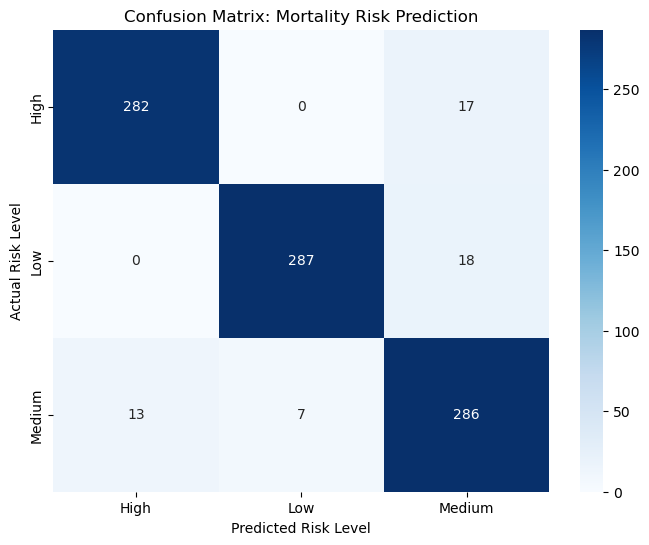

In [7]:
# CONFUSION MATRIX VISUALIZATION
# Understanding where the model is making misclassifications
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel('Predicted Risk Level')
plt.ylabel('Actual Risk Level')
plt.title('Confusion Matrix: Mortality Risk Prediction')
# SAVE FIGURE
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### Step 5: Feature Importance

C:\Users\Admin\AppData\Local\Temp\ipykernel_7108\1439621136.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


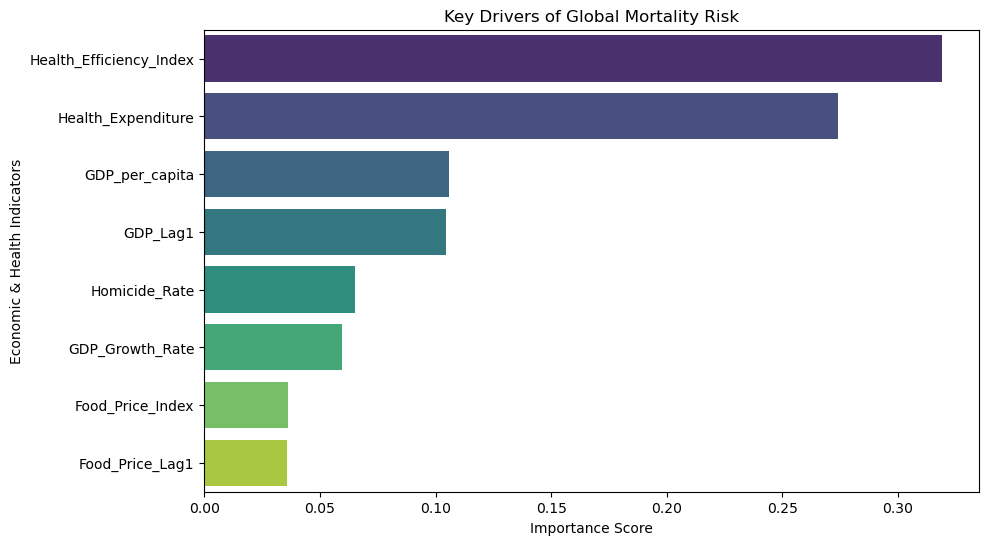

In [8]:
# FEATURE IMPORTANCE ANALYSIS
# Identifying which economic or health signals drive mortality risk


# Extracting importance from the Random Forest model
importances = rf_model.feature_importances_
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Visualizing Top Drivers
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title('Key Drivers of Global Mortality Risk')
plt.xlabel('Importance Score')
plt.ylabel('Economic & Health Indicators')
# SAVE FIGURE
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

### Step 6: Saving the Final Model

In [9]:
# Save the model and the label encoder together for the dashboard
model_data = {
    'model': rf_model,
    'features': features,
    'le': le
}
joblib.dump(model_data, 'mortality_model_final.pkl')
print("Success: Final Model and Metadata saved for Streamlit!")

Success: Final Model and Metadata saved for Streamlit!
